# Livingston Township (07039) — Sales Trends

Historical sales-trend analysis from county property records (`data/merged.csv`).

Pipeline: **load & clean** → **filter to a segment** → **plot trends** (median price, volume, $/sqft).

Edit the `FILTERS` cell to slice by year range, beds, or property class, then re-run the plot cells.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

DATA = Path("..") / "data" / "merged.csv"
assert DATA.exists(), f"missing {DATA.resolve()} — run the merge step first"

## 1. Load & clean

Parses dates and numerics, then flags rows that should be excluded from price trends:

- **non-arms-length / nominal sales** — price < $1,000 (the data has thousands of $0–$10 transfers: estate, LLC, intra-family, deed corrections).
- **unparseable sale dates**.

`df` = everything; `clean` = arms-length residential-usable rows. `$/sqft` additionally needs `Sq Ft > 0`.

In [2]:
raw = pd.read_csv(DATA, dtype=str)

df = raw.copy()
df["sale_date"] = pd.to_datetime(df["Sale Date"], format="%m/%d/%Y", errors="coerce")
df["price"]   = pd.to_numeric(df["Sale Price"], errors="coerce")
df["sqft"]    = pd.to_numeric(df["Sq Ft"], errors="coerce")
df["beds"]    = pd.to_numeric(df["Beds"], errors="coerce")
df["year"]    = df["sale_date"].dt.year
df["ppsf"]    = df["price"] / df["sqft"].where(df["sqft"] > 0)

MIN_PRICE = 1_000
df["arms_length"] = df["price"] >= MIN_PRICE

clean = df[df["sale_date"].notna() & df["arms_length"]].copy()

print(f"raw rows:        {len(df):,}")
print(f"dropped (no date): {df['sale_date'].isna().sum():,}")
print(f"dropped (price < ${MIN_PRICE:,}): {(~df['arms_length']).sum():,}")
print(f"clean rows:      {len(clean):,}")
print(f"date range:      {clean['sale_date'].min():%Y-%m-%d} → {clean['sale_date'].max():%Y-%m-%d}")

raw rows:        20,309
dropped (no date): 4
dropped (price < $1,000): 5,479
clean rows:      14,828
date range:      1987-05-18 → 2026-03-30


## 2. Filters

Set the segment to analyze. `None` means "no filter on that field". Re-run from here down after changing.

In [3]:
FILTERS = dict(
    property_class="Residential",   # e.g. "Residential", "Commercial", or None for all
    year_min=2000,                  # or None
    year_max=None,
    beds=None,                      # exact bed count, e.g. 3, or None
)

def apply_filters(data, property_class=None, year_min=None, year_max=None, beds=None):
    d = data
    if property_class is not None:
        d = d[d["Property Class"] == property_class]
    if year_min is not None:
        d = d[d["year"] >= year_min]
    if year_max is not None:
        d = d[d["year"] <= year_max]
    if beds is not None:
        d = d[d["beds"] == beds]
    return d

seg = apply_filters(clean, **FILTERS)
label = ", ".join(f"{k}={v}" for k, v in FILTERS.items() if v is not None) or "all sales"
print(f"segment: {label}")
print(f"rows in segment: {len(seg):,}")

segment: property_class=Residential, year_min=2000
rows in segment: 11,985


## 3. Yearly trend table

Median price is the headline (robust to the occasional multi-million-dollar outlier); mean shown alongside. `ppsf` excludes zero-sqft rows.

In [4]:
yearly = seg.groupby("year").agg(
    sales=("price", "size"),
    median_price=("price", "median"),
    mean_price=("price", "mean"),
    median_ppsf=("ppsf", "median"),
).round(0)
yearly

,sales,median_price,mean_price,median_ppsf
year,,,,
"2,000",450,"300,000","359,420",157
"2,001",381,"320,000","436,498",168
"2,002",481,"350,000","407,790",187
"2,003",428,"385,000","453,431",206
"2,004",447,"459,000","576,267",247
"2,005",525,"515,000","622,050",279
"2,006",458,"555,995","646,945",296
"2,007",373,"557,500","717,241",283
"2,008",324,"528,000","623,347",264


## 4. Price trend over time

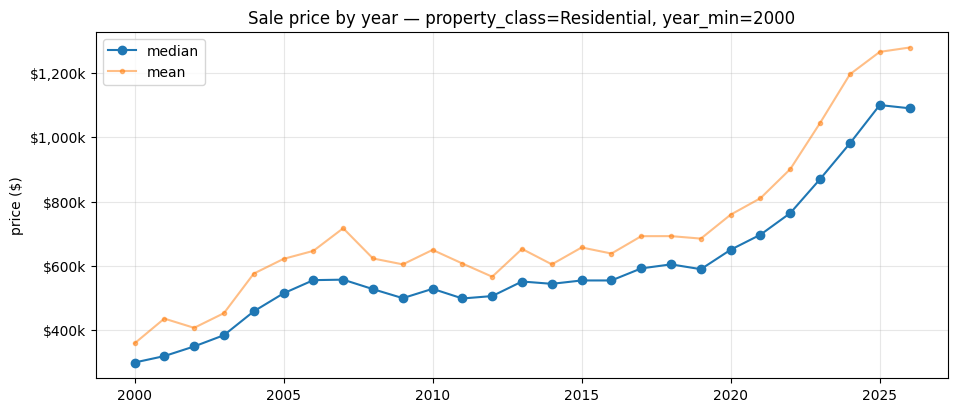

In [5]:
fig, ax = plt.subplots()
ax.plot(yearly.index, yearly["median_price"], marker="o", label="median")
ax.plot(yearly.index, yearly["mean_price"], marker=".", alpha=0.5, label="mean")
ax.set_title(f"Sale price by year — {label}")
ax.set_ylabel("price ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:,.0f}k")
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 5. Sales volume by year

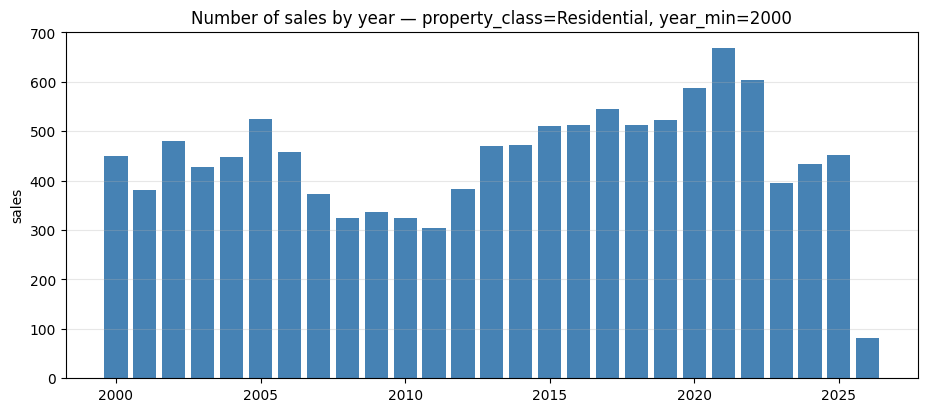

In [6]:
fig, ax = plt.subplots()
ax.bar(yearly.index, yearly["sales"], color="steelblue")
ax.set_title(f"Number of sales by year — {label}")
ax.set_ylabel("sales")
ax.grid(alpha=0.3, axis="y")
plt.show()

## 6. Price per square foot by year

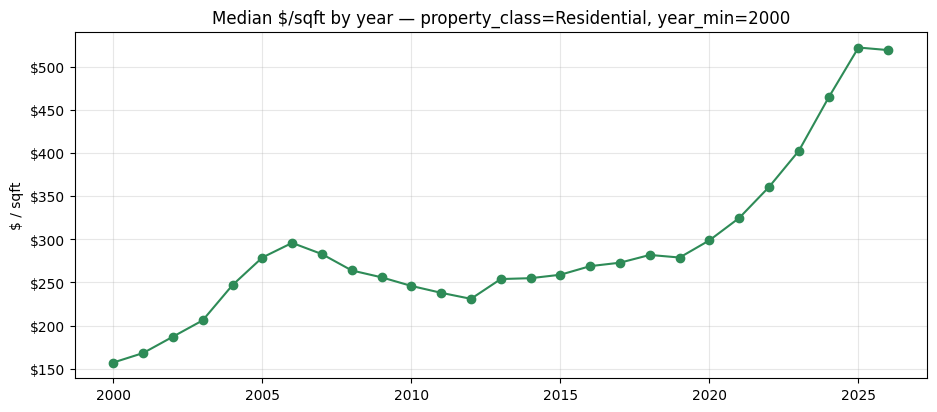

In [7]:
ppsf = yearly["median_ppsf"].dropna()
fig, ax = plt.subplots()
ax.plot(ppsf.index, ppsf.values, marker="o", color="seagreen")
ax.set_title(f"Median $/sqft by year — {label}")
ax.set_ylabel("$ / sqft")
ax.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
ax.grid(alpha=0.3)
plt.show()

## 7. Monthly stats

Finer-grained than yearly. Views below: a year-month **time series**, **seasonality** (by calendar month), **year-over-year** change, and **% vs. prior year-end** for the last 15 years.

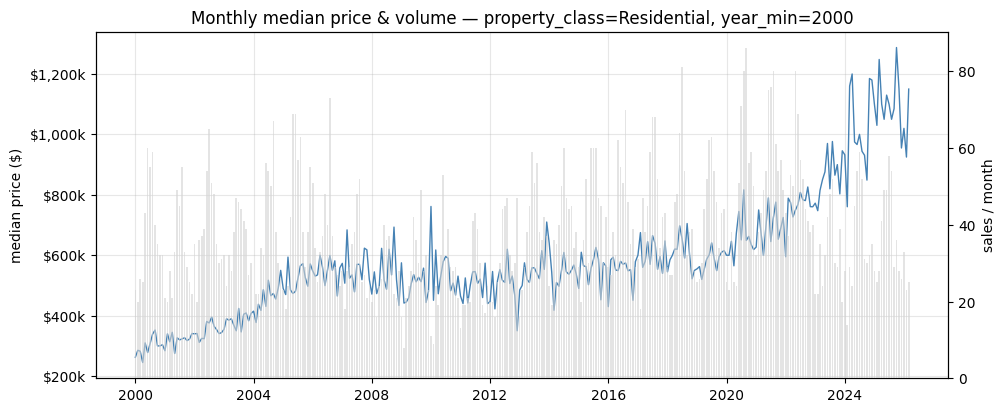

,sales,median_price,median_ppsf
ym,,,
2025-04,41,"1,100,000",514
2025-05,49,"1,050,000",503
2025-06,49,"1,130,000",549
2025-07,58,"1,100,000",523
2025-08,54,"1,050,000",540
2025-09,29,"1,085,000",487
2025-10,36,"1,287,500",579
2025-11,28,"1,150,000",534
2025-12,26,"955,000",478


In [8]:
monthly = seg.copy()
monthly["ym"] = monthly["sale_date"].dt.to_period("M")
monthly = monthly.groupby("ym").agg(
    sales=("price", "size"),
    median_price=("price", "median"),
    median_ppsf=("ppsf", "median"),
).round(0)

# plot monthly median price + volume (volume on a twin axis)
idx = monthly.index.to_timestamp()
fig, ax = plt.subplots()
ax.plot(idx, monthly["median_price"], color="steelblue", lw=1, label="median price")
ax.set_ylabel("median price ($)")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:,.0f}k")
ax.set_title(f"Monthly median price & volume — {label}")
ax2 = ax.twinx()
ax2.bar(idx, monthly["sales"], width=20, color="lightgray", alpha=0.6, label="sales")
ax2.set_ylabel("sales / month")
ax.grid(alpha=0.3)
plt.show()

monthly.tail(12)

### Seasonality

Metrics aggregated by calendar month across all years in the segment — which months sell most / priciest.

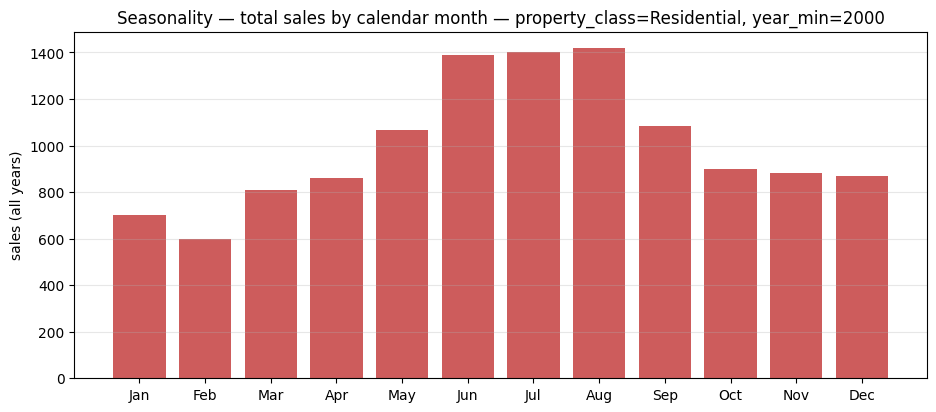

,sales,median_price,median_ppsf
Jan,703,"551,000",263
Feb,597,"554,000",257
Mar,811,"580,000",262
Apr,860,"550,000",265
May,1068,"570,000",264
Jun,1390,"575,000",269
Jul,1404,"595,000",276
Aug,1418,"605,000",276
Sep,1086,"565,000",266
Oct,899,"575,000",264


In [9]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
season = seg.assign(month=seg["sale_date"].dt.month).groupby("month").agg(
    sales=("price", "size"),
    median_price=("price", "median"),
    median_ppsf=("ppsf", "median"),
).round(0)
season.index = [MONTHS[m - 1] for m in season.index]

fig, ax = plt.subplots()
ax.bar(season.index, season["sales"], color="indianred")
ax.set_title(f"Seasonality — total sales by calendar month — {label}")
ax.set_ylabel("sales (all years)")
ax.grid(alpha=0.3, axis="y")
plt.show()

season

### Year-over-year price change

Each month's median price vs. the **same month one year earlier** (cancels seasonality). Monthly YoY is noisy at ~30 sales/month, so a **12-month rolling-median YoY** is shown alongside as the steadier signal.

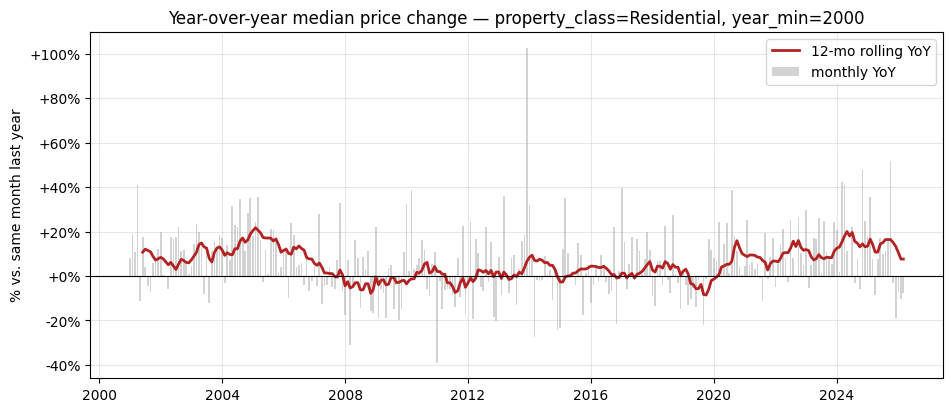

,sales,median_price,yoy_%,yoy_smooth_%
2025-04,41,"1,100,000",-8,11
2025-05,49,"1,050,000",8,11
2025-06,49,"1,130,000",17,14
2025-07,58,"1,100,000",10,15
2025-08,54,"1,050,000",11,16
2025-09,29,"1,085,000",16,16
2025-10,36,"1,287,500",52,16
2025-11,28,"1,150,000",-3,15
2025-12,26,"955,000",-19,13
2026-01,33,"1,020,000",-7,11


In [10]:
# reindex to a continuous monthly range so shift(12) lands on exactly the same
# month a year earlier even if some month had no sales.
yoy = monthly.reindex(pd.period_range(monthly.index.min(), monthly.index.max(), freq="M"))
yoy["yoy_%"] = (yoy["median_price"] / yoy["median_price"].shift(12) - 1) * 100
yoy["smooth"] = yoy["median_price"].rolling(12, min_periods=6).median()
yoy["yoy_smooth_%"] = (yoy["smooth"] / yoy["smooth"].shift(12) - 1) * 100

t = yoy.index.to_timestamp()
fig, ax = plt.subplots()
ax.bar(t, yoy["yoy_%"], width=20, color="lightgray", label="monthly YoY")
ax.plot(t, yoy["yoy_smooth_%"], color="firebrick", lw=2, label="12-mo rolling YoY")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Year-over-year median price change — {label}")
ax.set_ylabel("% vs. same month last year")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
ax.grid(alpha=0.3); ax.legend()
plt.show()

yoy[["sales", "median_price", "yoy_%", "yoy_smooth_%"]].tail(12).round(1)

### Monthly % change vs. prior year-end (last 20 years)

Each month's median price as a **% change from the prior calendar year's median**
(the basis resets each January). E.g. a `+27` in 2025-Mar means March 2025's
median ran 27% above the 2024 full-year median. Rows = year, columns = month, for
the **last 20 years** (earlier years have too few sales/month and swing wildly).
The `Avg` row averages each month down the years. Respects the property-class /
beds `FILTERS` but **not** the year range. The current year is partial.

In [11]:
# Basis = prior calendar year's median. Use class/beds filters but ignore the
# year range. Last 20 years only — earlier years have too few sales/month, so
# their monthly medians swing wildly and would distort the table & Avg.
base = apply_filters(clean, property_class=FILTERS["property_class"], beds=FILTERS["beds"])
base = base.assign(month=base["sale_date"].dt.month)

yearly_med = base.groupby("year")["price"].median()
mm = base.groupby(["year", "month"])["price"].median().rename("median").reset_index()
mm["pct"] = (mm["median"] / mm["year"].sub(1).map(yearly_med) - 1) * 100

last20 = sorted(base["year"].dropna().unique())[-20:]
pct_table = (mm[mm["year"].isin(last20)]
             .pivot(index="year", columns="month", values="pct")
             .reindex(columns=range(1, 13)))
pct_table.columns = MONTHS
pct_table.index = pct_table.index.astype(int)

# append a column-average row (mean of each month down the years, skipping NaNs)
pct_table.loc["Avg"] = pct_table.mean(axis=0)

pct_table.style.format("{:+.1f}%", na_rep="—").background_gradient(
    cmap="RdYlGn", axis=None, vmin=-20, vmax=20)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2007,+3.1%,-8.7%,+23.0%,-5.8%,-3.8%,-13.9%,+2.5%,+2.5%,-6.7%,+12.1%,+11.2%,-6.5%
2008,-15.4%,-2.2%,-15.2%,-10.8%,+11.7%,-7.2%,-12.6%,+11.2%,-4.0%,+24.3%,-6.7%,-22.2%
2009,+8.9%,-16.3%,-15.7%,-13.1%,-4.3%,+1.5%,-3.0%,-0.1%,-2.9%,+5.6%,-16.0%,-9.1%
2010,+52.3%,-9.8%,+23.5%,-5.5%,+6.0%,+15.8%,+19.2%,+18.0%,-3.5%,+1.6%,-6.4%,+6.2%
2011,-12.1%,-16.8%,-0.8%,-16.4%,-5.5%,+3.0%,+3.2%,-4.2%,-1.5%,-13.0%,+8.5%,-16.8%
2012,-10.6%,+9.5%,-15.3%,+3.2%,+10.7%,+3.7%,+2.2%,+24.2%,+1.5%,+6.5%,-6.3%,-29.9%
2013,-4.2%,-1.3%,+13.5%,+2.7%,+0.7%,+10.2%,+10.2%,+6.6%,+3.2%,+21.5%,+9.2%,+40.2%
2014,+16.0%,-1.4%,-24.2%,-7.6%,-9.8%,-0.7%,+10.4%,-1.2%,-2.7%,-0.3%,+2.9%,-2.6%
2015,-10.0%,+12.0%,+3.8%,+3.3%,-7.7%,+2.2%,+7.4%,+15.0%,+8.0%,-16.9%,+5.6%,+3.8%


### Seasonal % change vs. prior year-end (last 20 years)

Same basis as above (prior calendar year's median), but pooled into 3-month
seasons: **Dec–Feb, Mar–May, Jun–Aug, Sep–Nov**. Each season's median uses all
sales in its three months, then compared to the prior year's median. Winter
(Dec–Feb) is labeled by the year it ends in, so its December comes from the prior
calendar year. Pooling ~3 months of sales makes each cell steadier than the
single-month table. `Avg` row averages each season down the years.

In [12]:
SEASON = {12: "Dec-Feb", 1: "Dec-Feb", 2: "Dec-Feb",
          3: "Mar-May", 4: "Mar-May", 5: "Mar-May",
          6: "Jun-Aug", 7: "Jun-Aug", 8: "Jun-Aug",
          9: "Sep-Nov", 10: "Sep-Nov", 11: "Sep-Nov"}
SEASON_ORDER = ["Dec-Feb", "Mar-May", "Jun-Aug", "Sep-Nov"]

s = base.copy()
s["season"] = s["month"].map(SEASON)
# label winter by the year it ends in: December rolls into next year's Dec-Feb
s["season_year"] = s["year"] + (s["month"] == 12).astype(int)

# pooled median across each season's 3 months, vs. prior calendar year's median
sm = s.groupby(["season_year", "season"])["price"].median().rename("median").reset_index()
sm["pct"] = (sm["median"] / sm["season_year"].sub(1).map(yearly_med) - 1) * 100

last20_s = sorted(s["season_year"].unique())[-20:]
season_table = (sm[sm["season_year"].isin(last20_s)]
                .pivot(index="season_year", columns="season", values="pct")
                .reindex(columns=SEASON_ORDER))
season_table.index = season_table.index.astype(int)
season_table.index.name = "year"
season_table.loc["Avg"] = season_table.mean(axis=0)

season_table.style.format("{:+.1f}%", na_rep="—").background_gradient(
    cmap="RdYlGn", axis=None, vmin=-20, vmax=20)

season,Dec-Feb,Mar-May,Jun-Aug,Sep-Nov
year,,,,
2007,+0.6%,+3.4%,-0.9%,+2.0%
2008,-6.7%,-9.4%,-2.2%,+0.0%
2009,-9.6%,-12.9%,-0.1%,-6.2%
2010,+0.0%,-0.0%,+16.0%,-1.3%
2011,-12.4%,-5.5%,+0.2%,+0.9%
2012,-8.6%,+3.2%,+5.7%,+0.7%
2013,-9.2%,+5.5%,+9.6%,+9.0%
2014,+13.9%,-11.2%,+3.5%,-1.2%
2015,+3.9%,-0.4%,+6.5%,-6.0%


## 8. Export the yearly summary

In [13]:
out = Path("..") / "output"
out.mkdir(exist_ok=True)
slug = label.replace(", ", "_").replace("=", "-").replace(" ", "")
path = out / f"yearly_{slug}.csv"
yearly.to_csv(path)
print("wrote", path)

wrote ../output/yearly_property_class-Residential_year_min-2000.csv
